In [1]:
from pathlib import Path
import os

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats 
import numpy as np

import modsnow_drought as msd


In [14]:
project_root = Path.cwd()  # use current directory as root
os.chdir(project_root)

print("Working directory set to:", Path.cwd())

Working directory set to: /Users/tillweiss/Desktop/MODSNOW/code


In [15]:
#project_root = Path().resolve().parent
#os.chdir(project_root)

#print("Working directory set to:", Path.cwd())

In [3]:
snow_p = '/Users/tillweiss/Desktop/MODSNOW/data/snow_altitude/amudarya_kerky_elevation_bands_0500m.txt'

ndvi_path = '/Users/tillweiss/Desktop/MODSNOW/data/pixel_filtered/NDVI_mean_wedge.csv'

ndvi = pd.read_csv(ndvi_path)
ndvi['Date'] = pd.to_datetime(ndvi['time'])
#ndvi = ndvi[['Date', 'NDVI']].rename(columns={'Mean': 'NDVI'})

snow_out = msd.process_snow(
    snow_path=snow_p,
    ndvi=ndvi,  
    out_csv='/Users/tillweiss/Desktop/MODSNOW/data/amudarya_kerky_elevation_agg.csv',
    window_days=16
)

/Users/tillweiss/Desktop/MODSNOW/code/modsnow_drought.py:37: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  snow = pd.read_csv(snow_path, delim_whitespace=True)


In [31]:
ndvi_path = '/Users/tillweiss/Desktop/MODSNOW/data/pixel_filtered/NDVI_mean_wedge.csv'
snow_path = '/Users/tillweiss/Desktop/MODSNOW/data/kafirnigan_tartki_elevation_agg.csv'

label = 'Mean Filtered Kafirnigan'
catchment = 'Kafirnigan'

In [29]:
ndvi = pd.read_csv(ndvi_path)

ndvi['Date'] = pd.to_datetime(ndvi['time'])
ndvi = ndvi[['Date', 'NDVI']]
#ndvi = ndvi.rename(columns={'NDVI': 'NDVI'})

In [ ]:
snow = pd.read_csv(snow_path, header = 0)
snow['Date'] = pd.to_datetime(snow['Date'])

,Date,Snow_16d,Year,Month,DOY
0,2000-02-18,100.00000,2000,2,49
1,2000-03-05,100.00000,2000,3,65
2,2000-03-21,100.00000,2000,3,81
3,2000-04-06,99.42125,2000,4,97
4,2000-04-22,92.51000,2000,4,113
...,...,...,...,...,...
583,2025-06-26,6.34000,2025,6,177
584,2025-07-12,1.52750,2025,7,193
585,2025-07-28,0.84625,2025,7,209
586,2025-08-13,0.65625,2025,8,225


In [ ]:
snow = snow[['Date', 'col_5_16d', 'Year', 'Month', 'DOY']]
snow = snow.rename(columns={'col_5_16d': 'Snow_16d'})

ndvi_snow = ndvi.join(snow.set_index('Date'), on='Date', how='inner')
ndvi_snow = ndvi_snow[ndvi_snow.Month.isin([3, 4, 5, 6, 7, 8, 9, 10])]



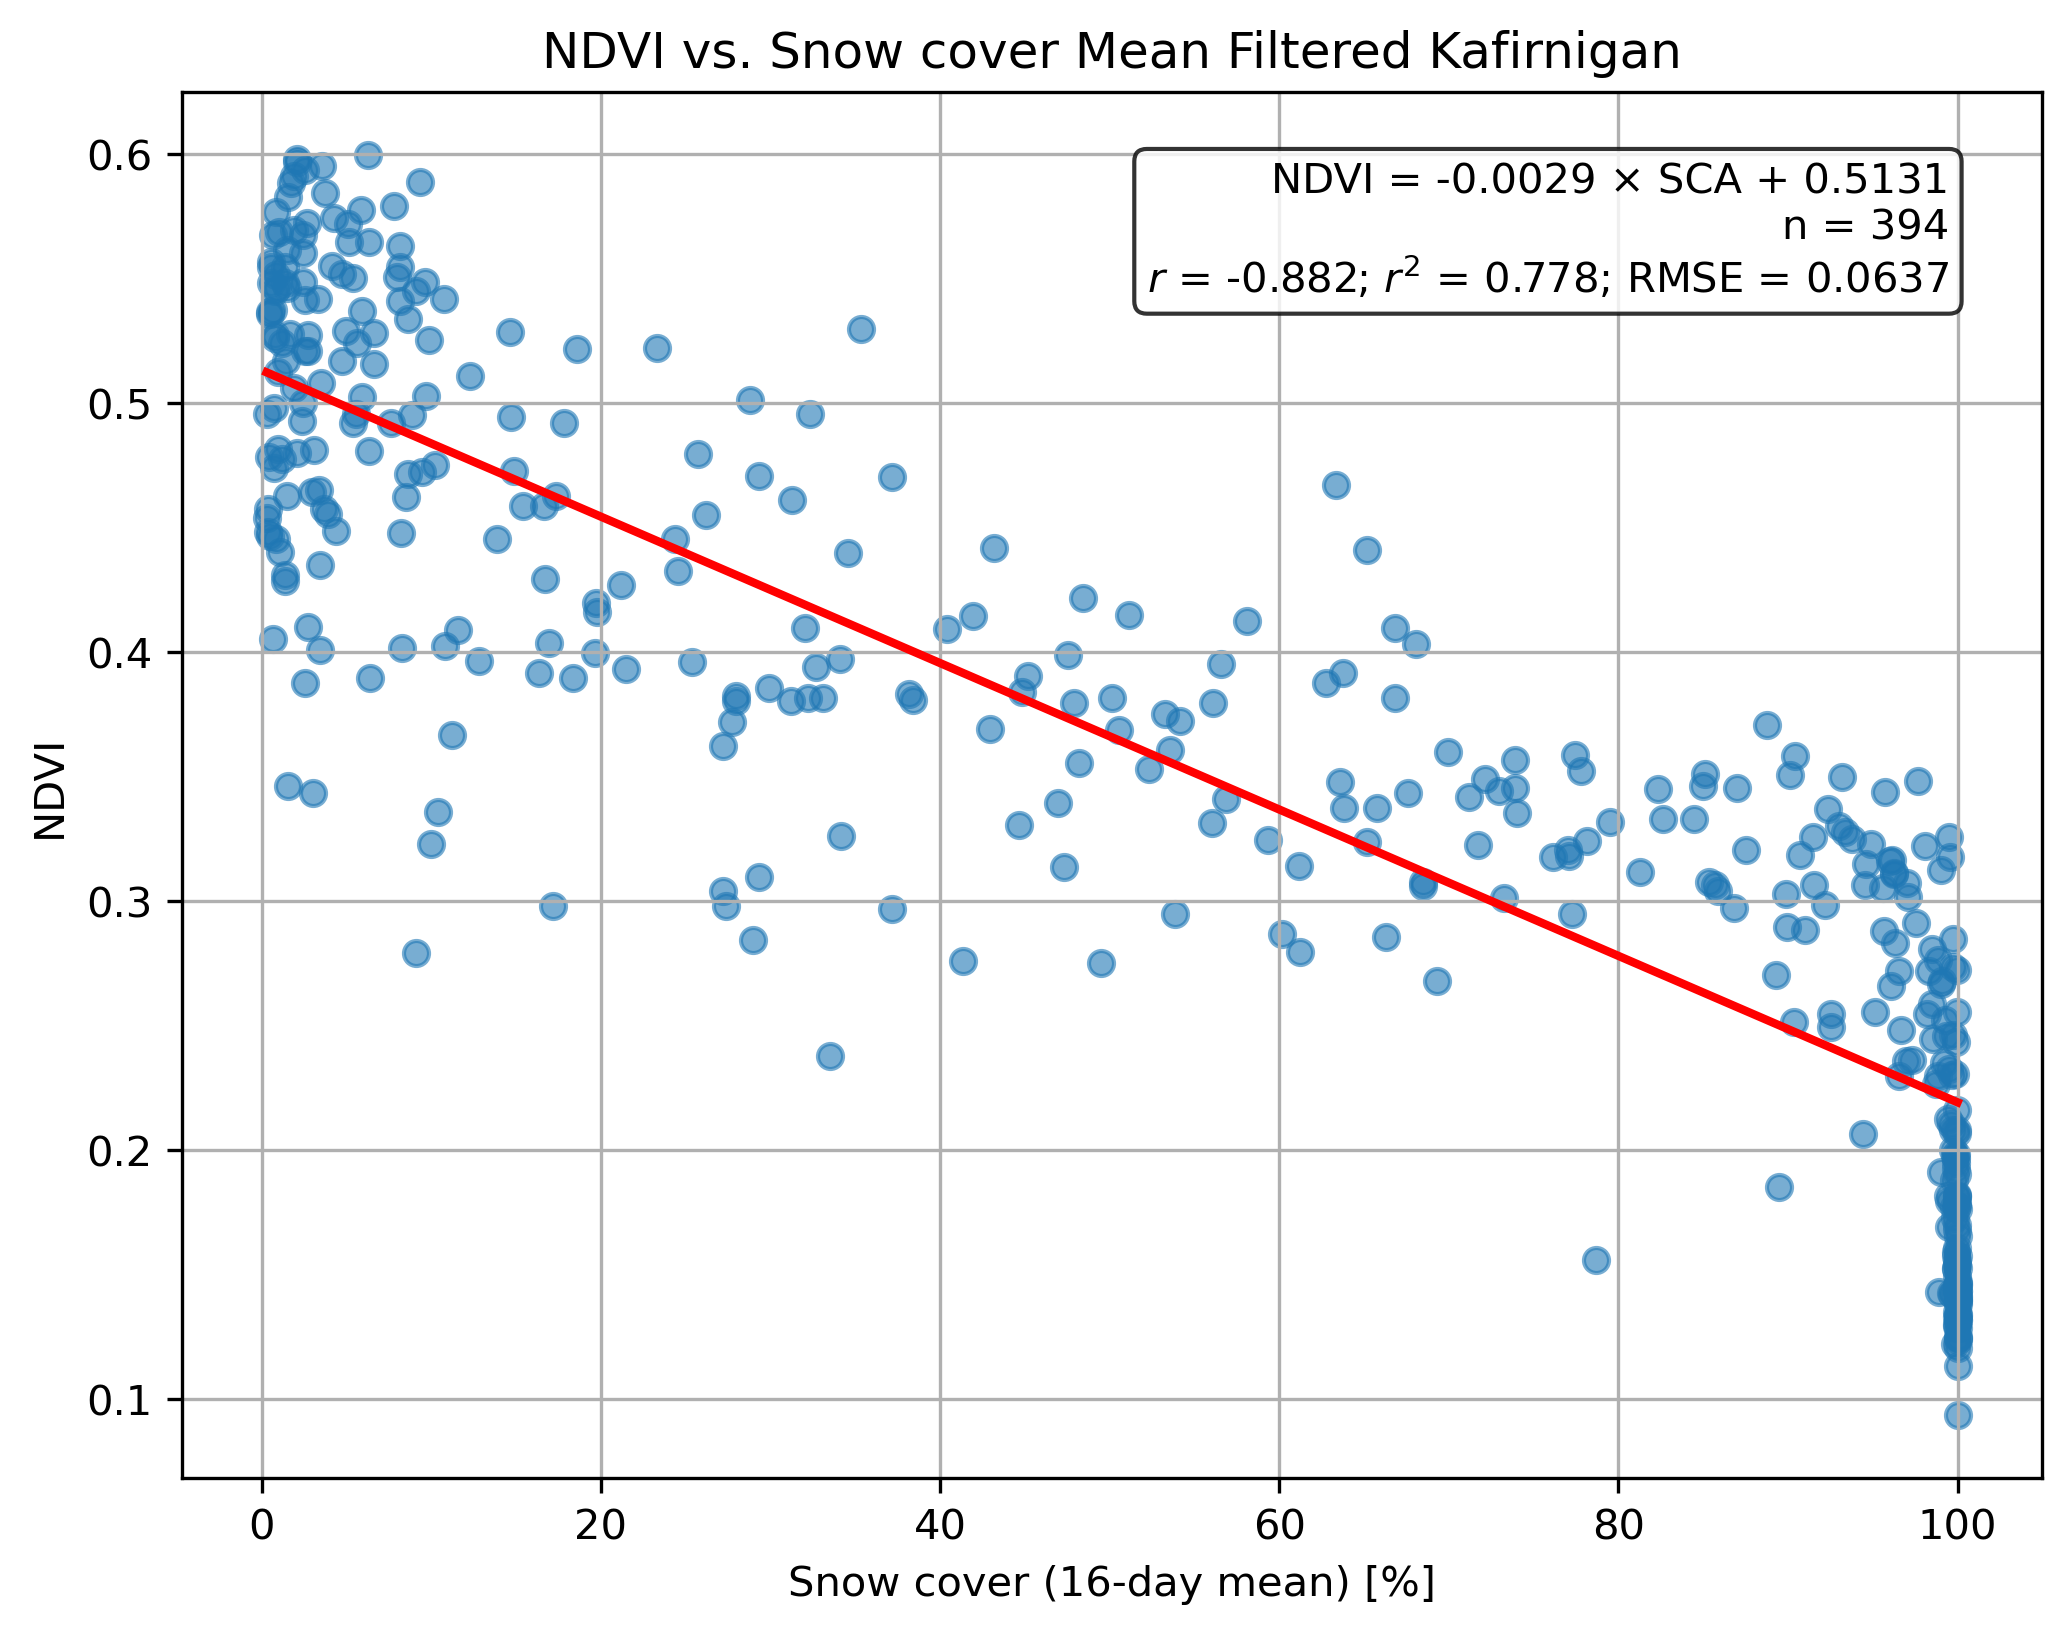

Pearson correlation: -0.882, p-value = 4.948e-130
Spearman correlation: -0.911, p-value = 9.936e-153
Regression slope: -0.0029
Regression intercept: 0.5131
Regression p-value: 4.948e-130


In [45]:
msd.plot_ndvi_timeseries(ndvi_snow, label)

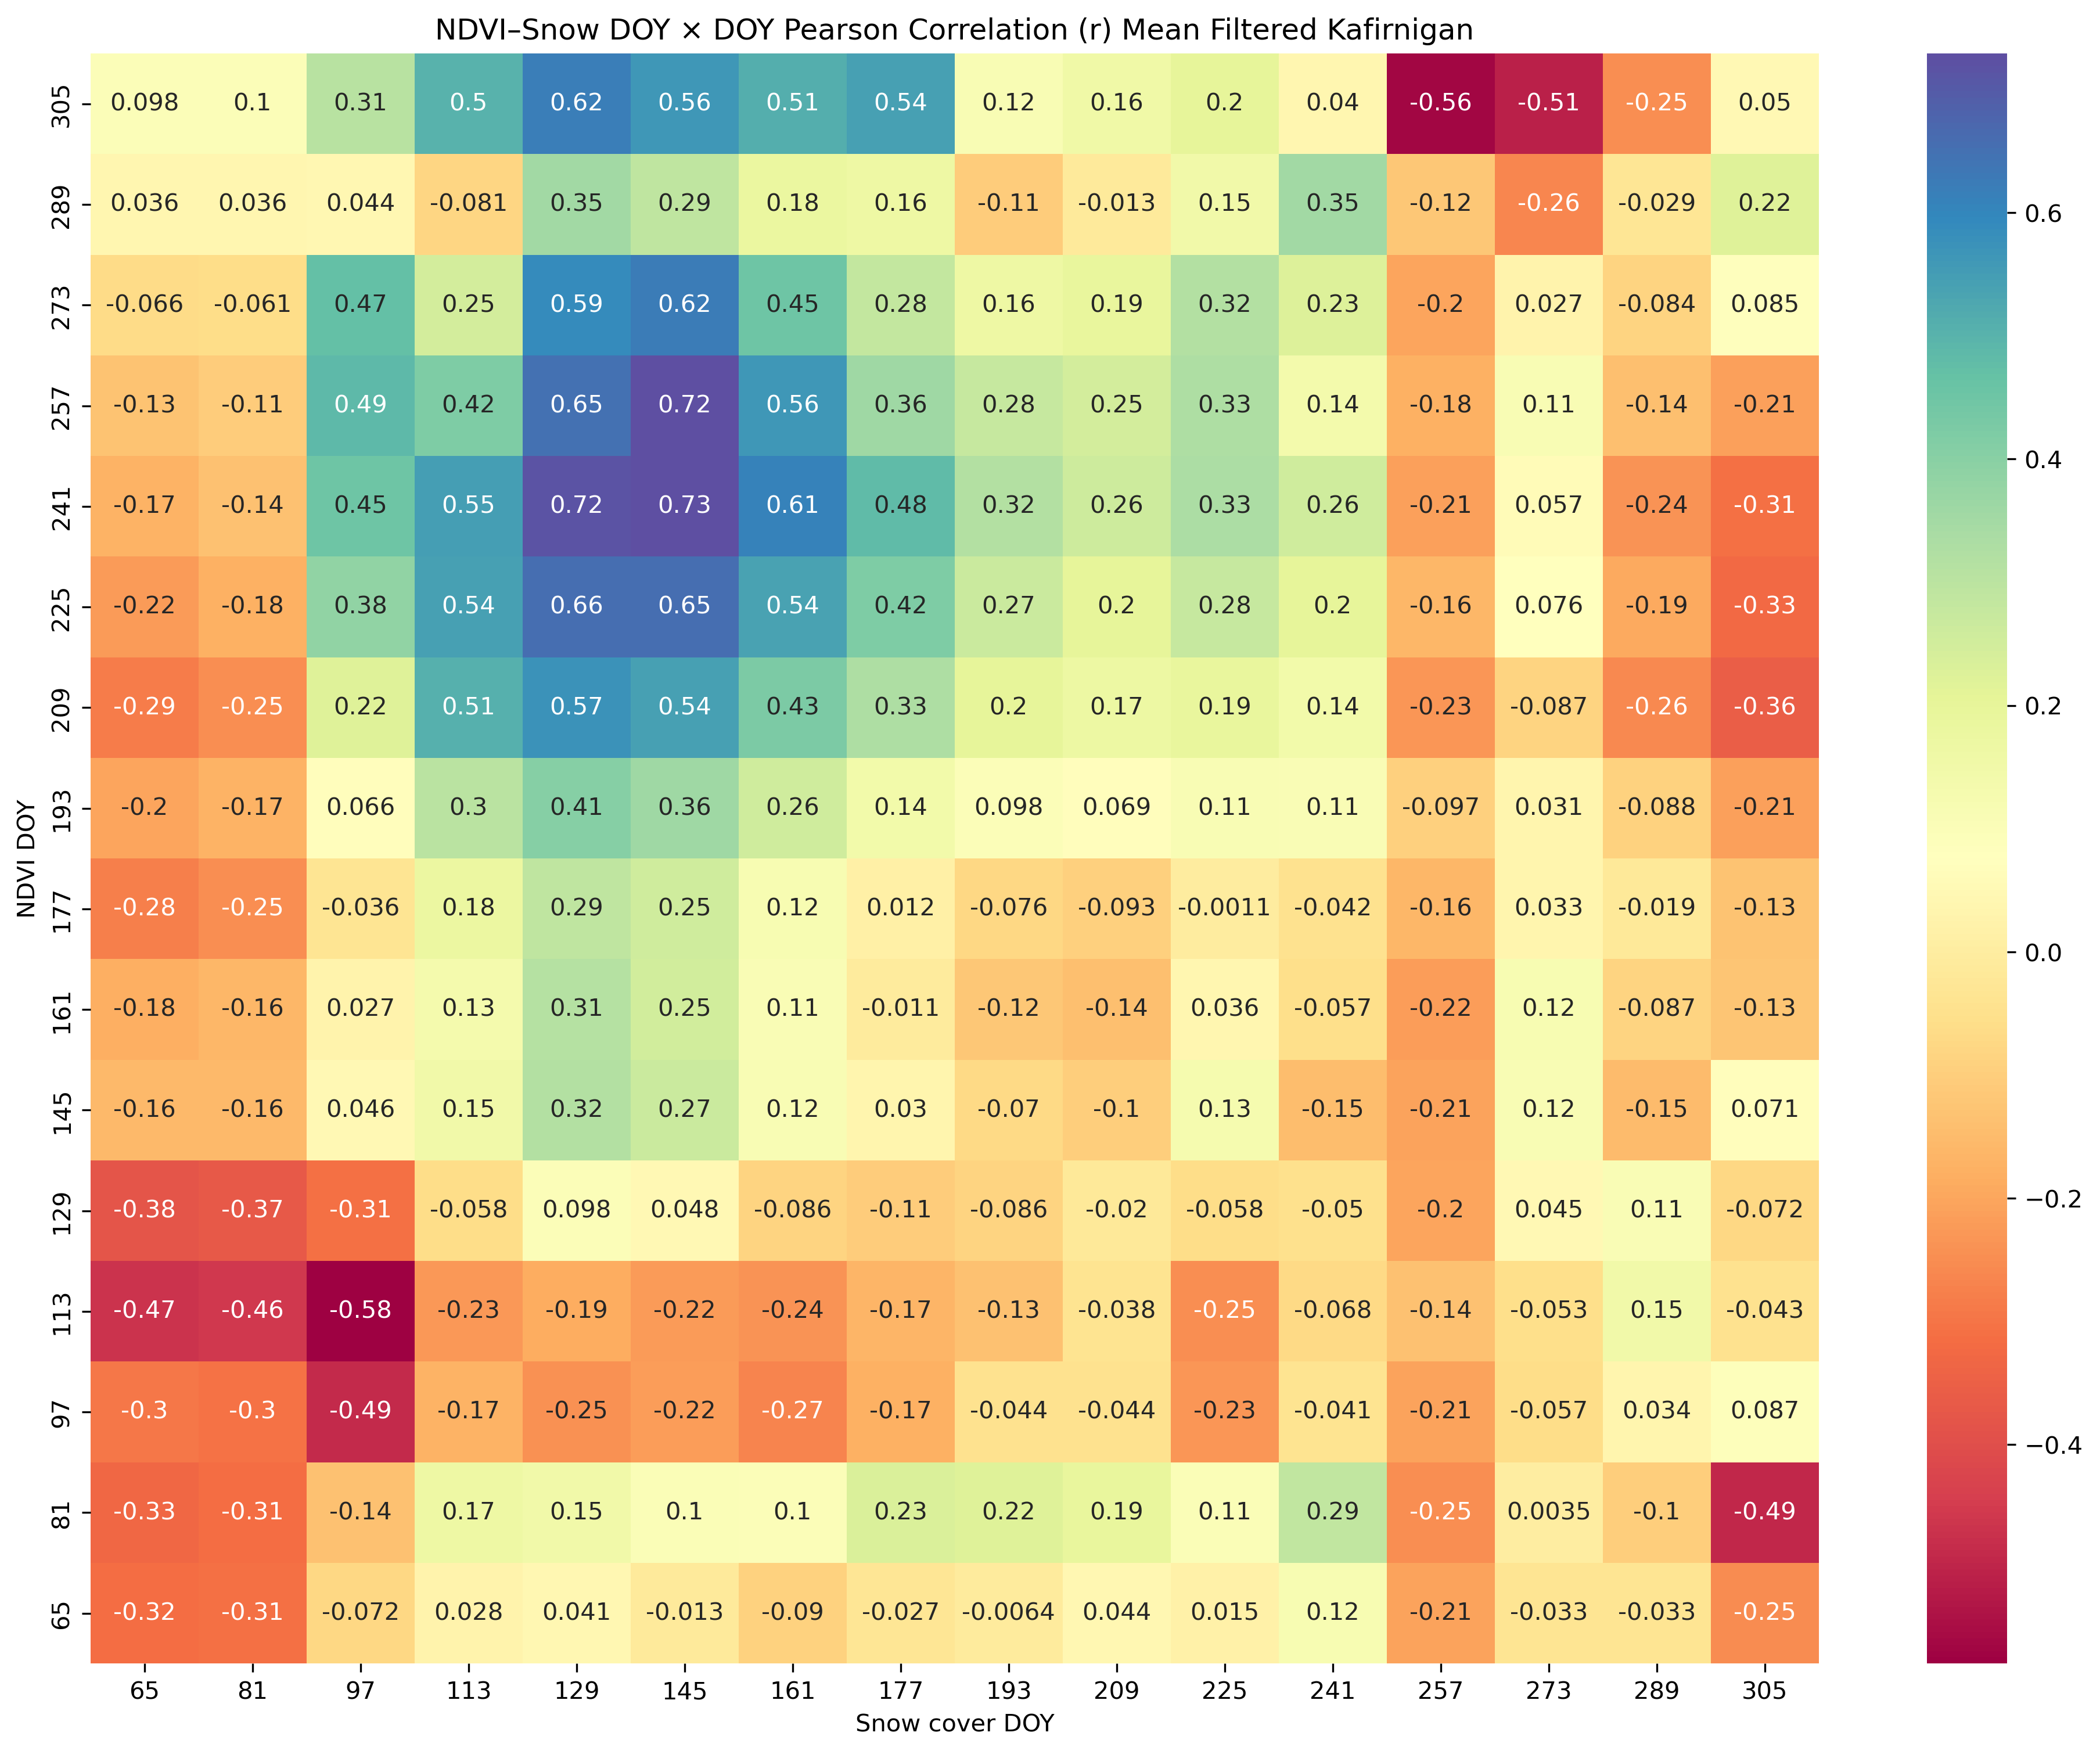

In [46]:
msd.compute_cor_heatmap(ndvi_snow, label)

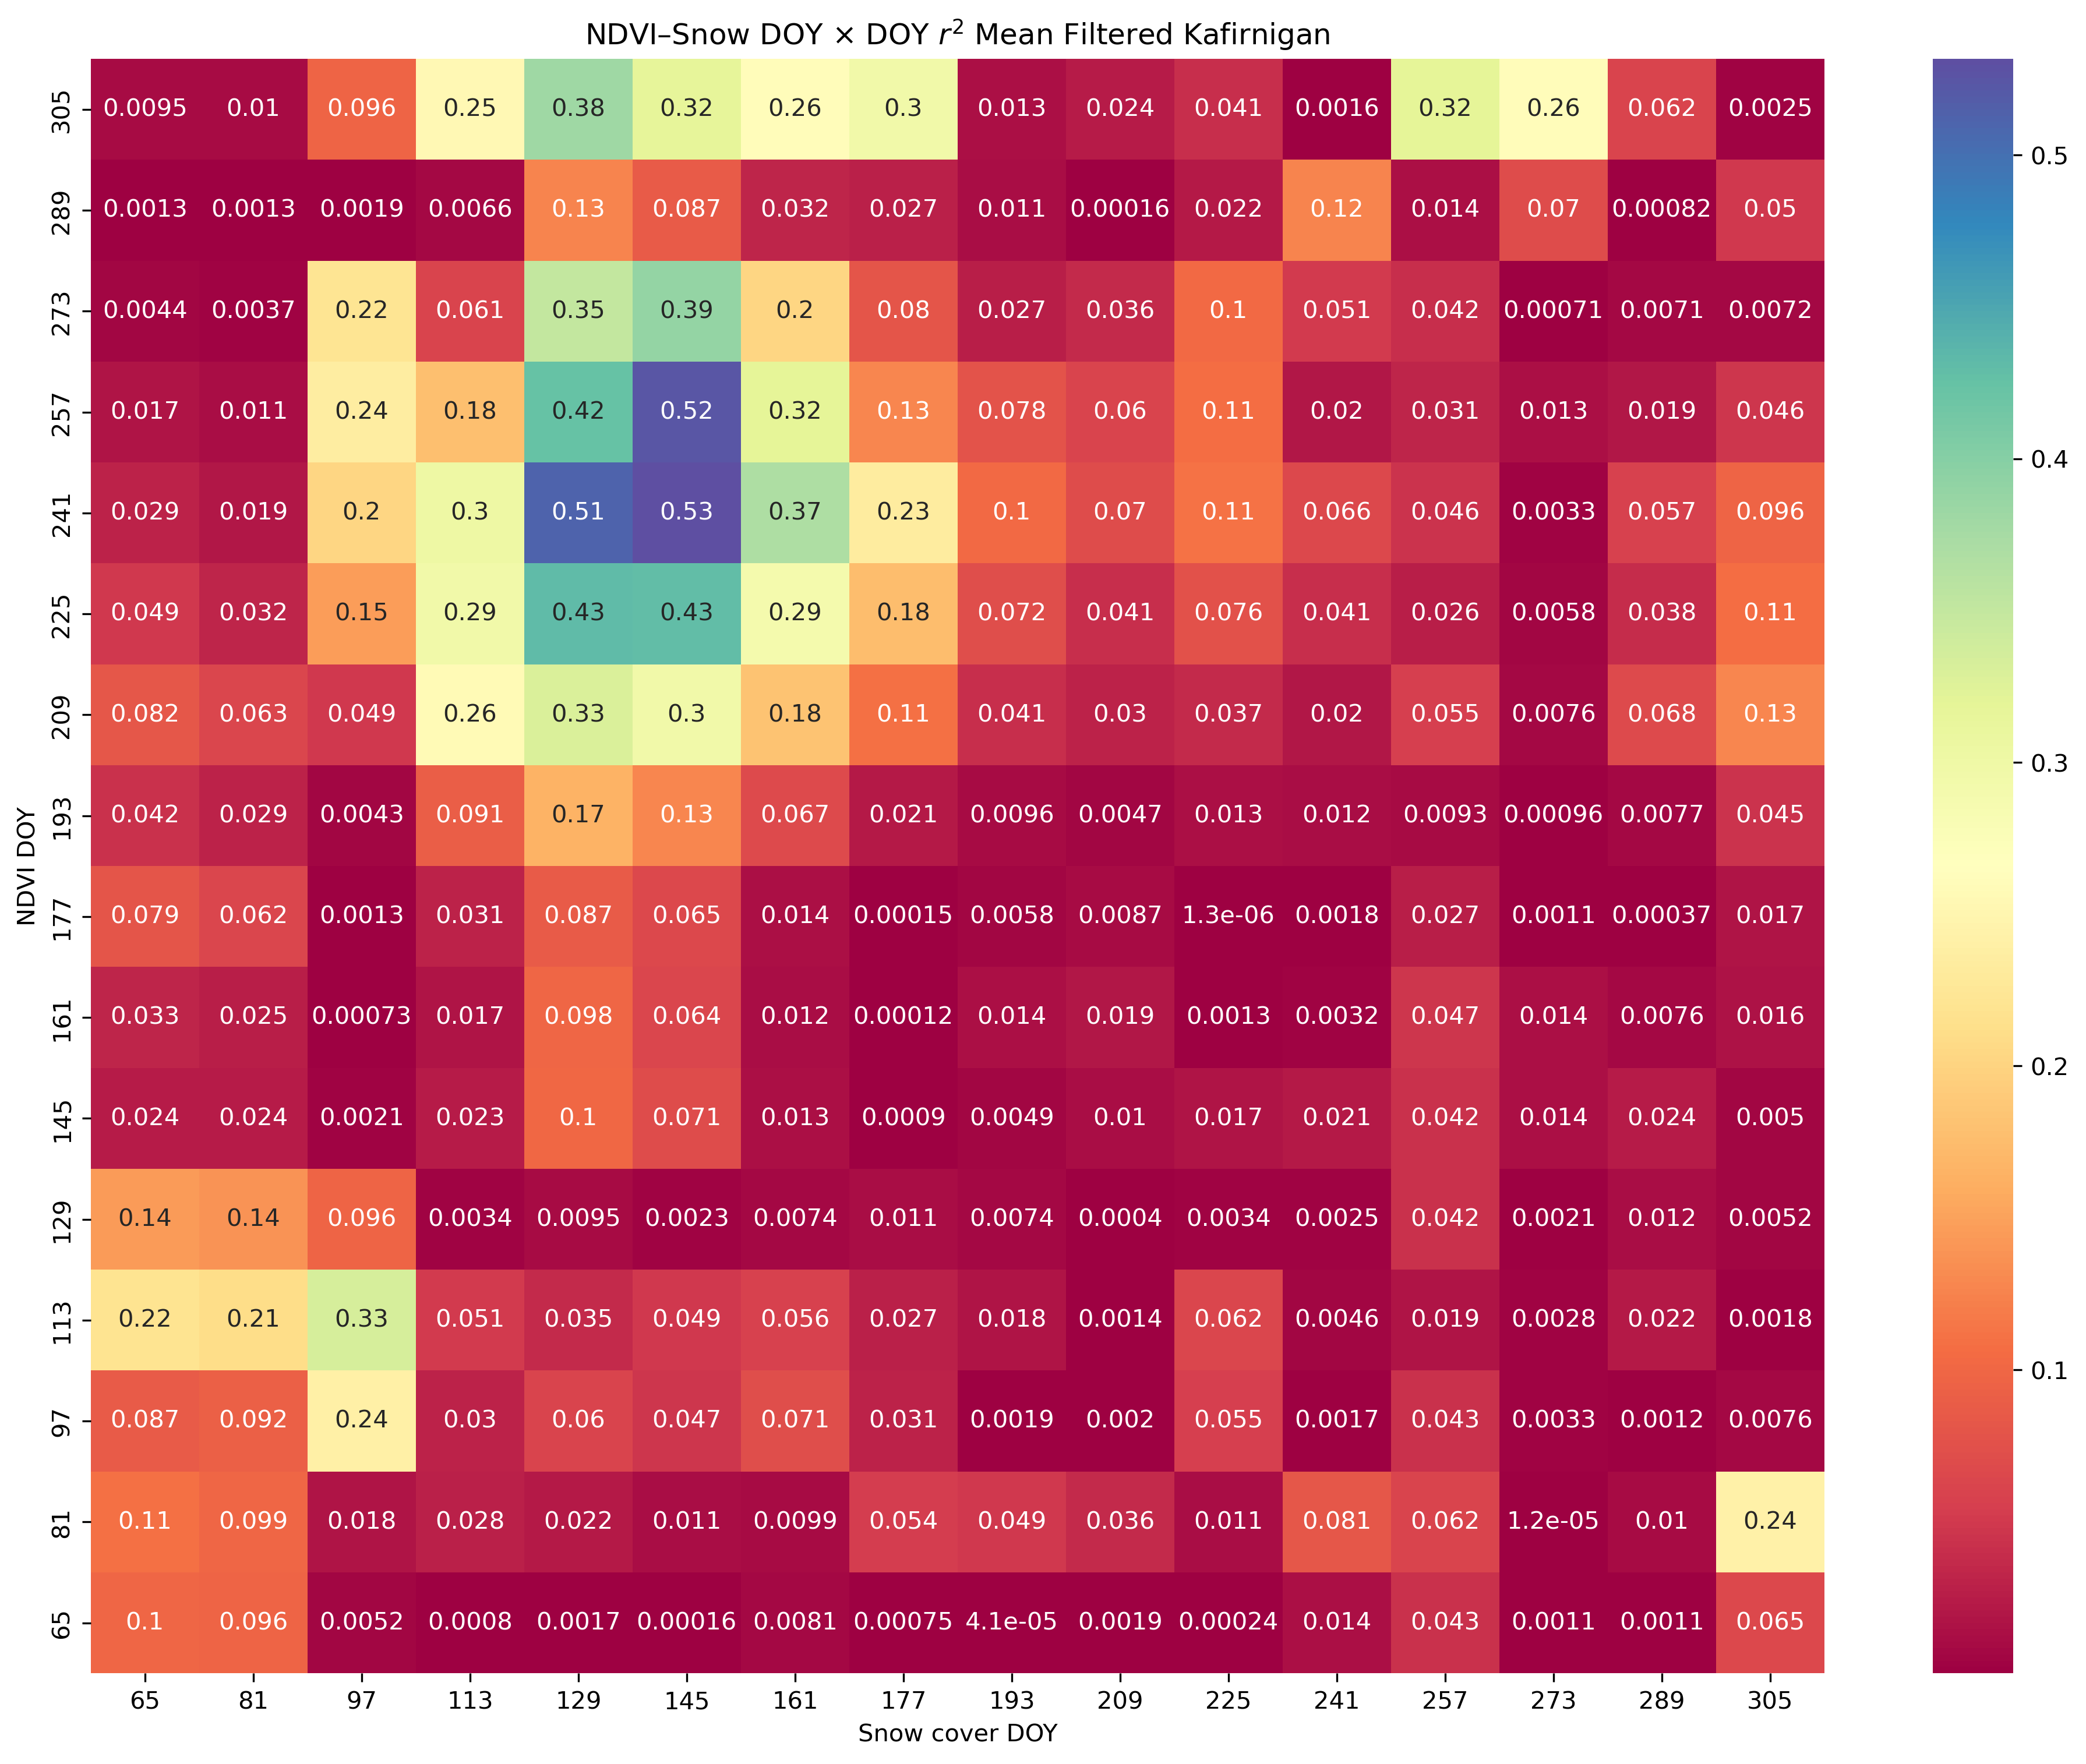

In [47]:
msd.compute_cor2_heatmap(ndvi_snow, label)

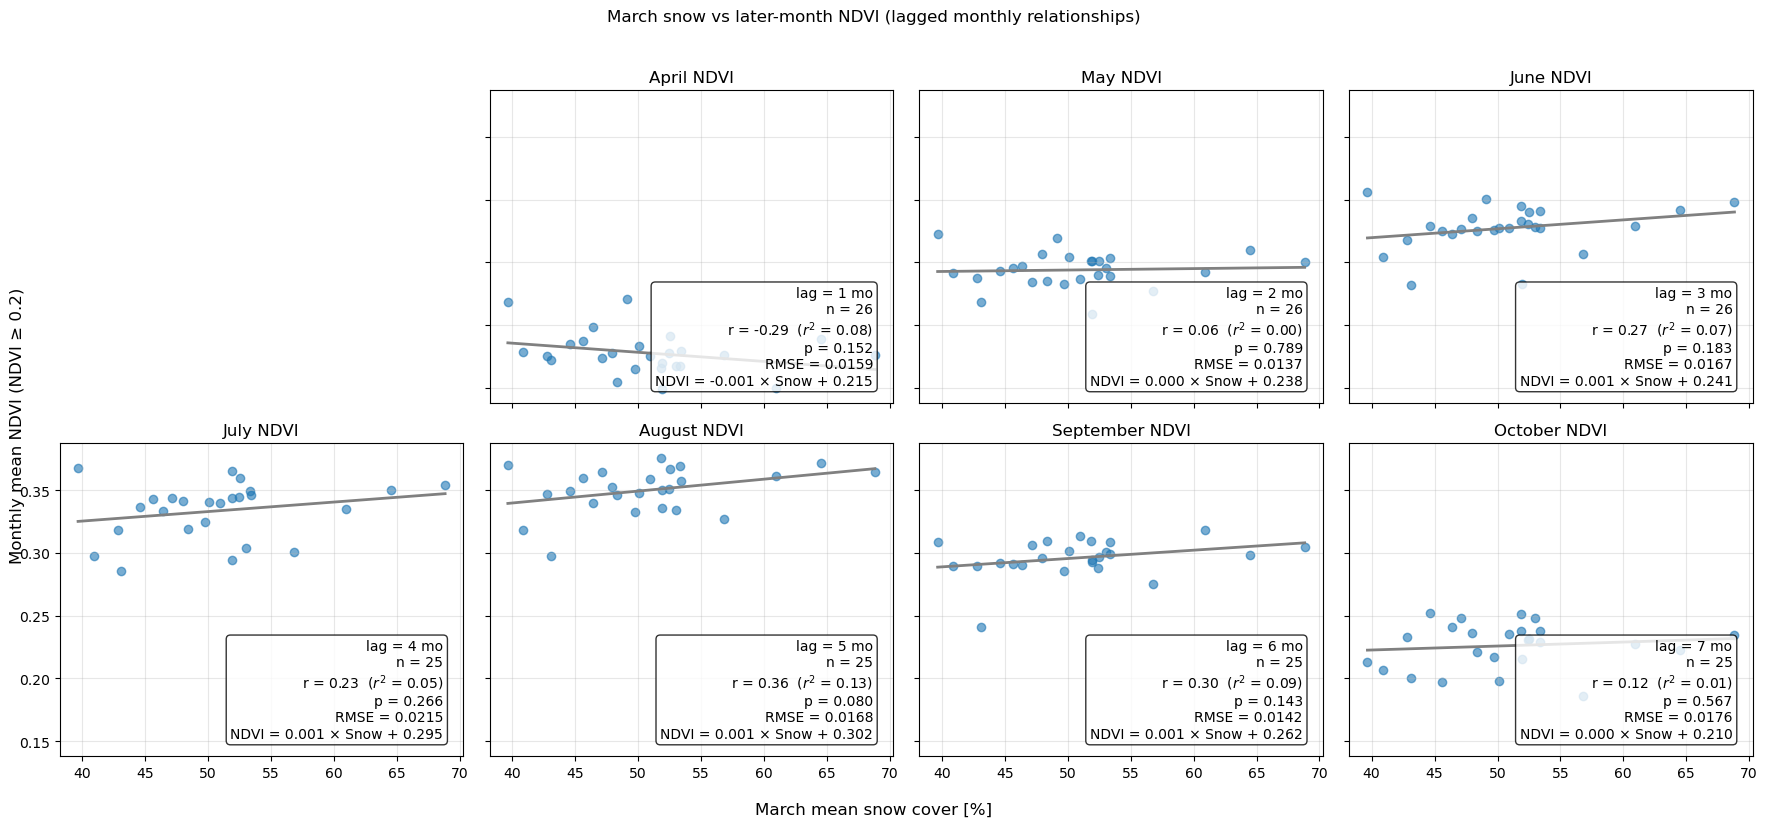

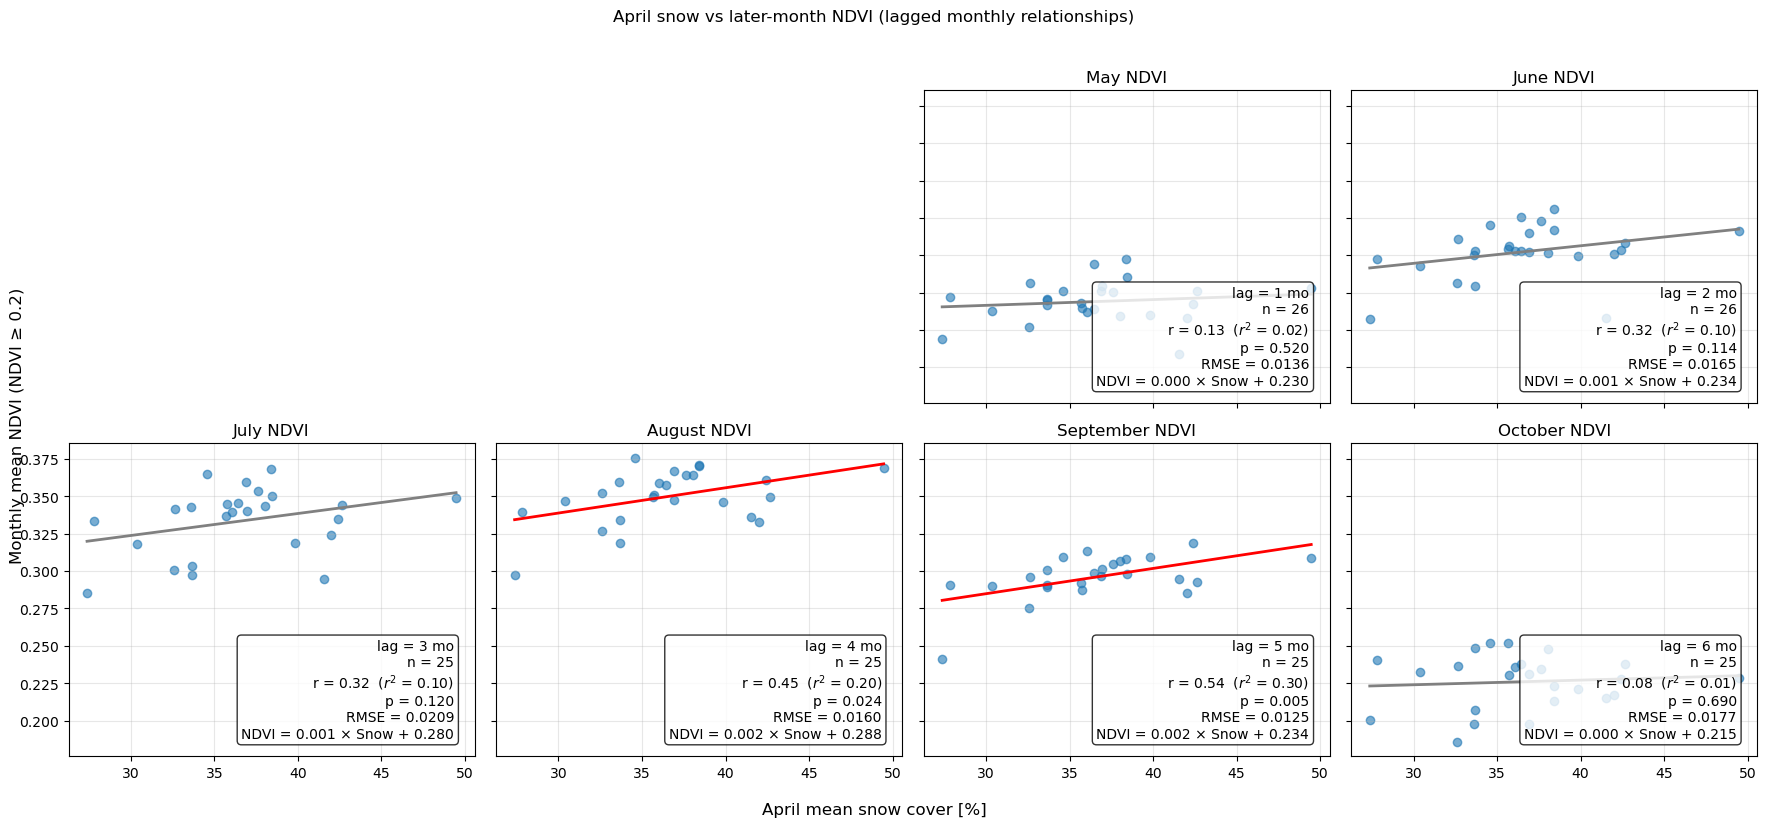

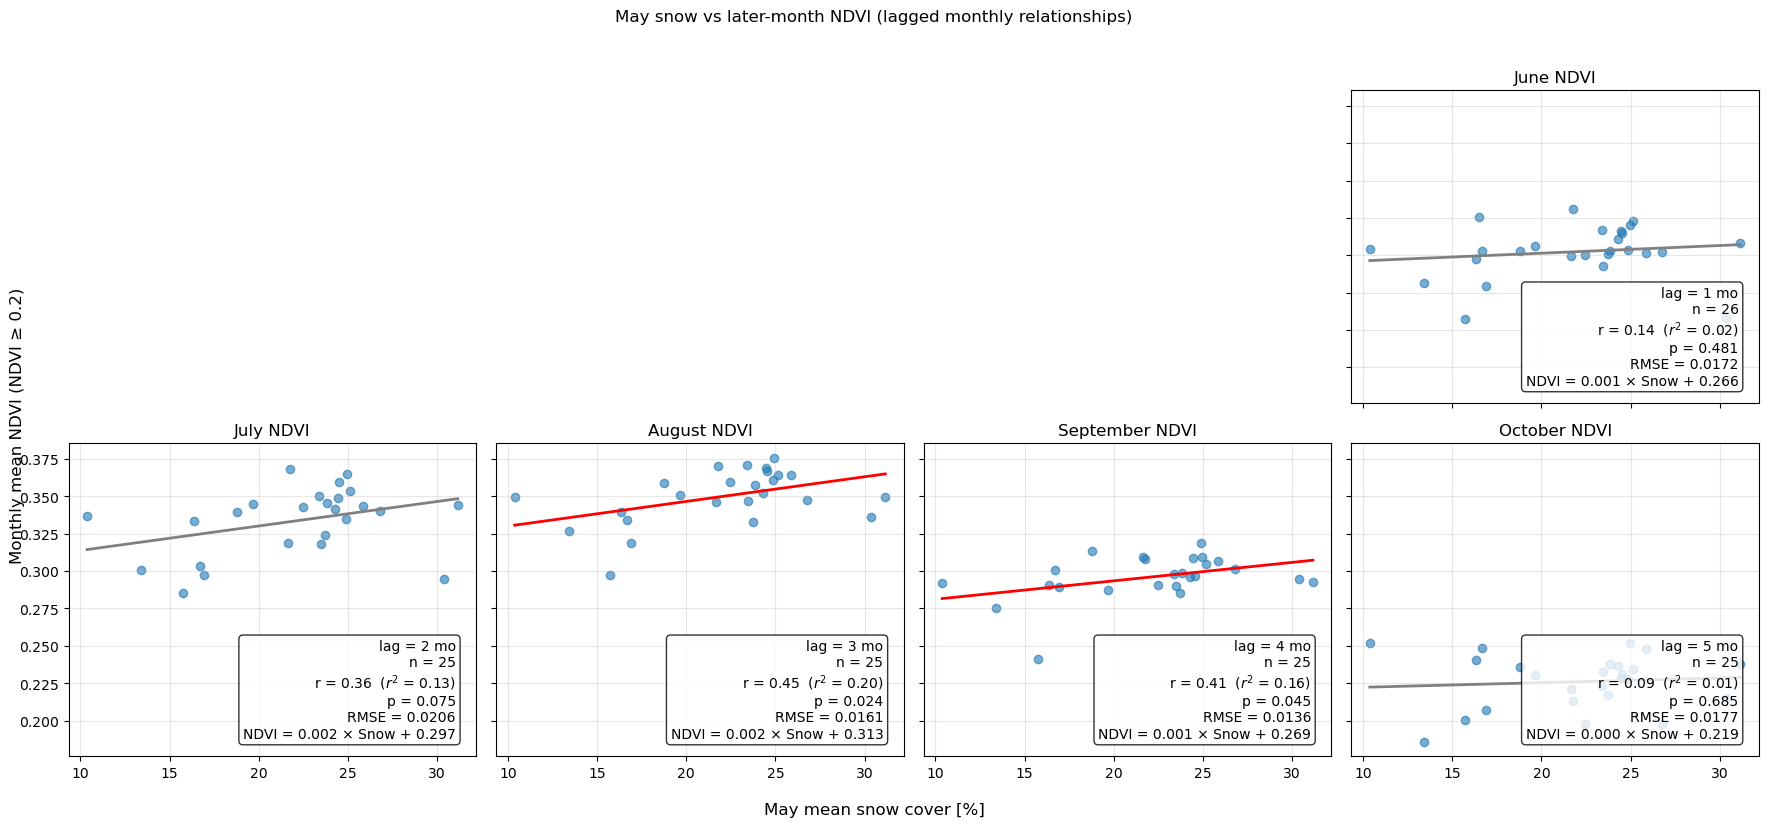

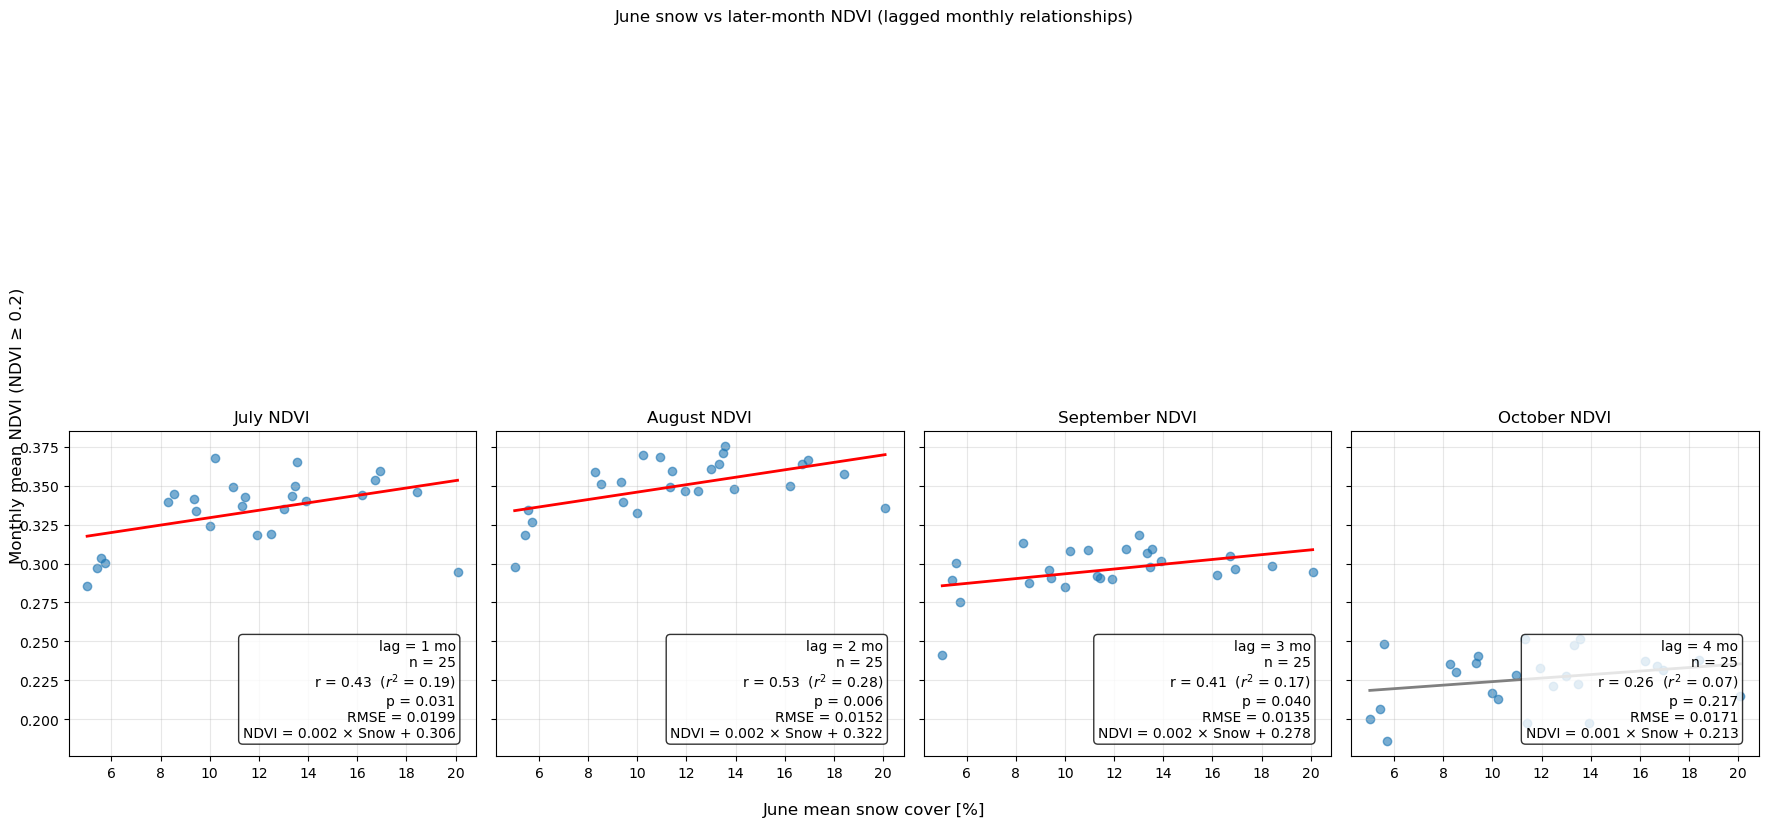

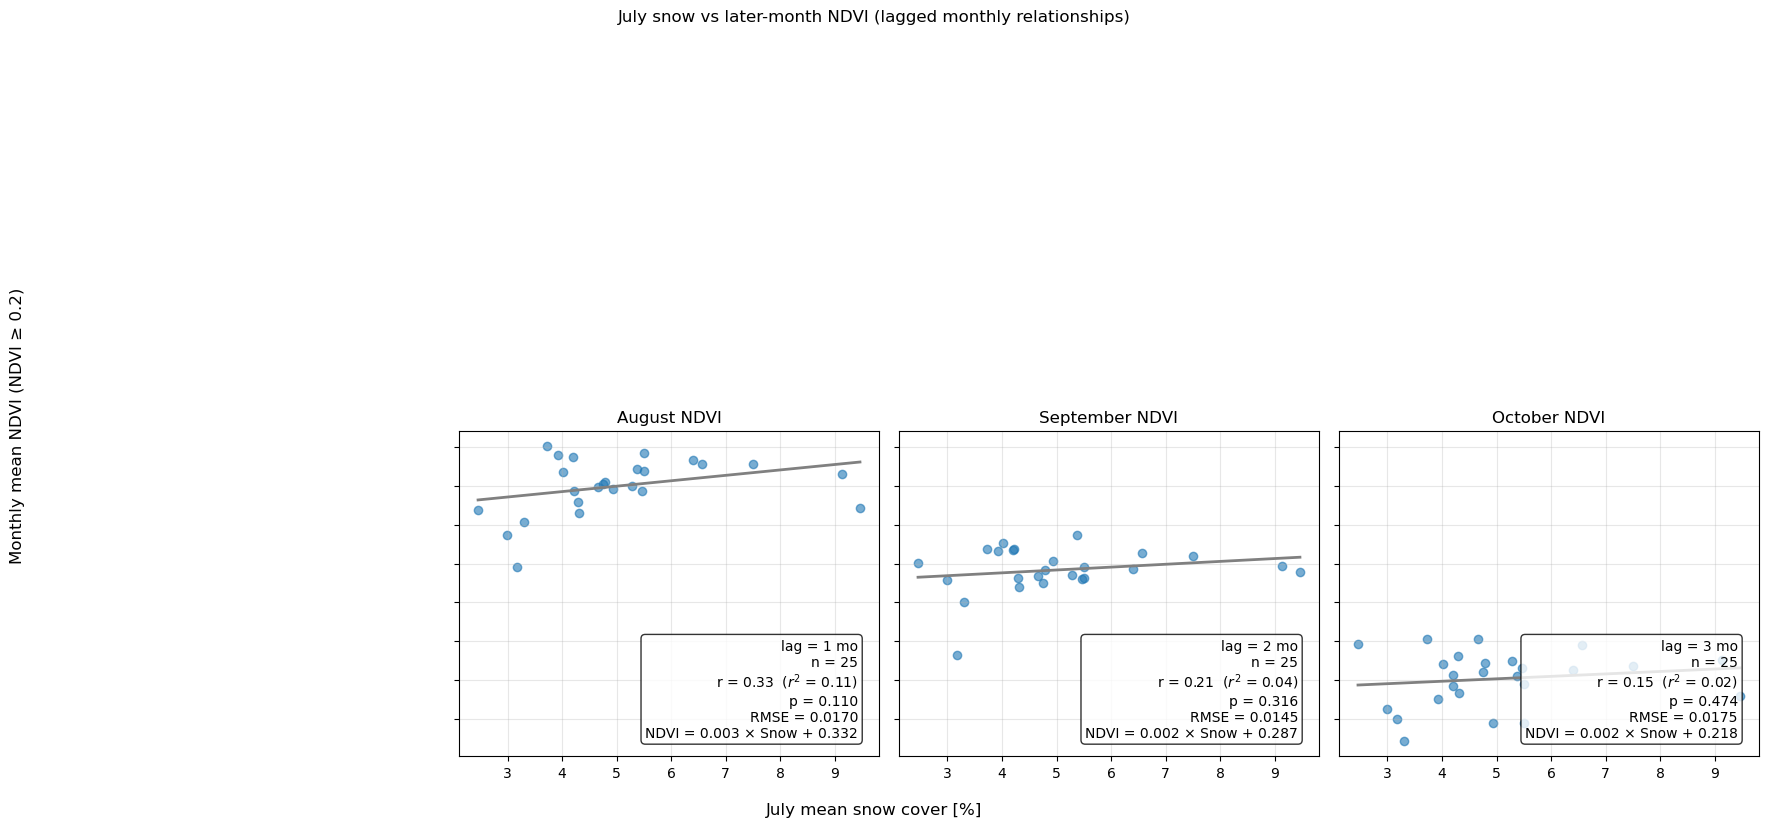

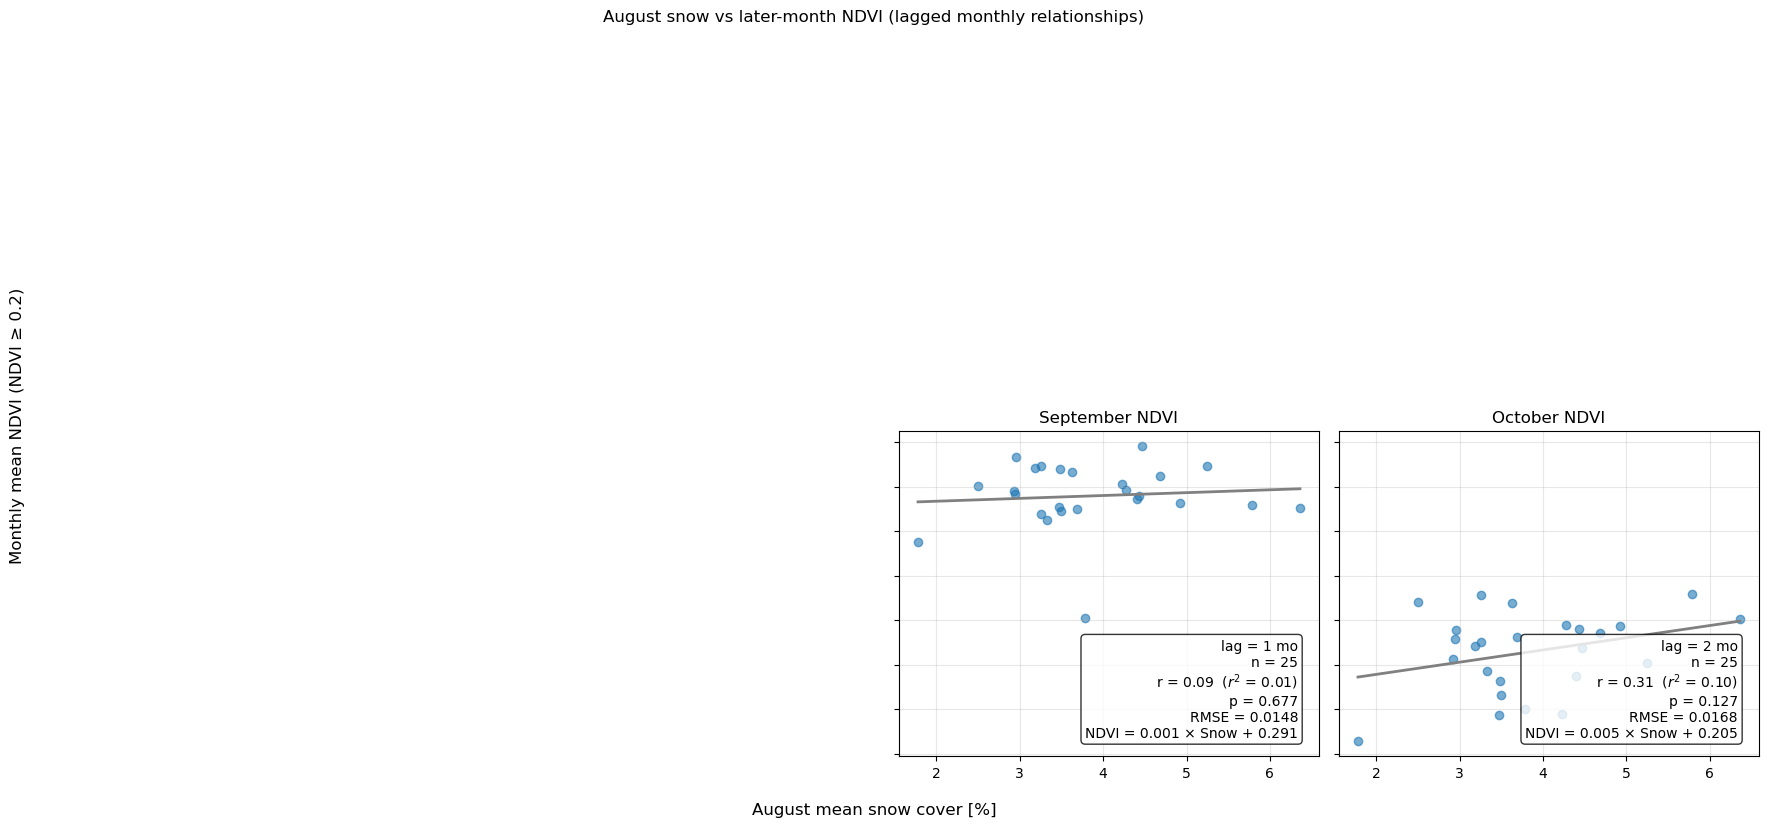

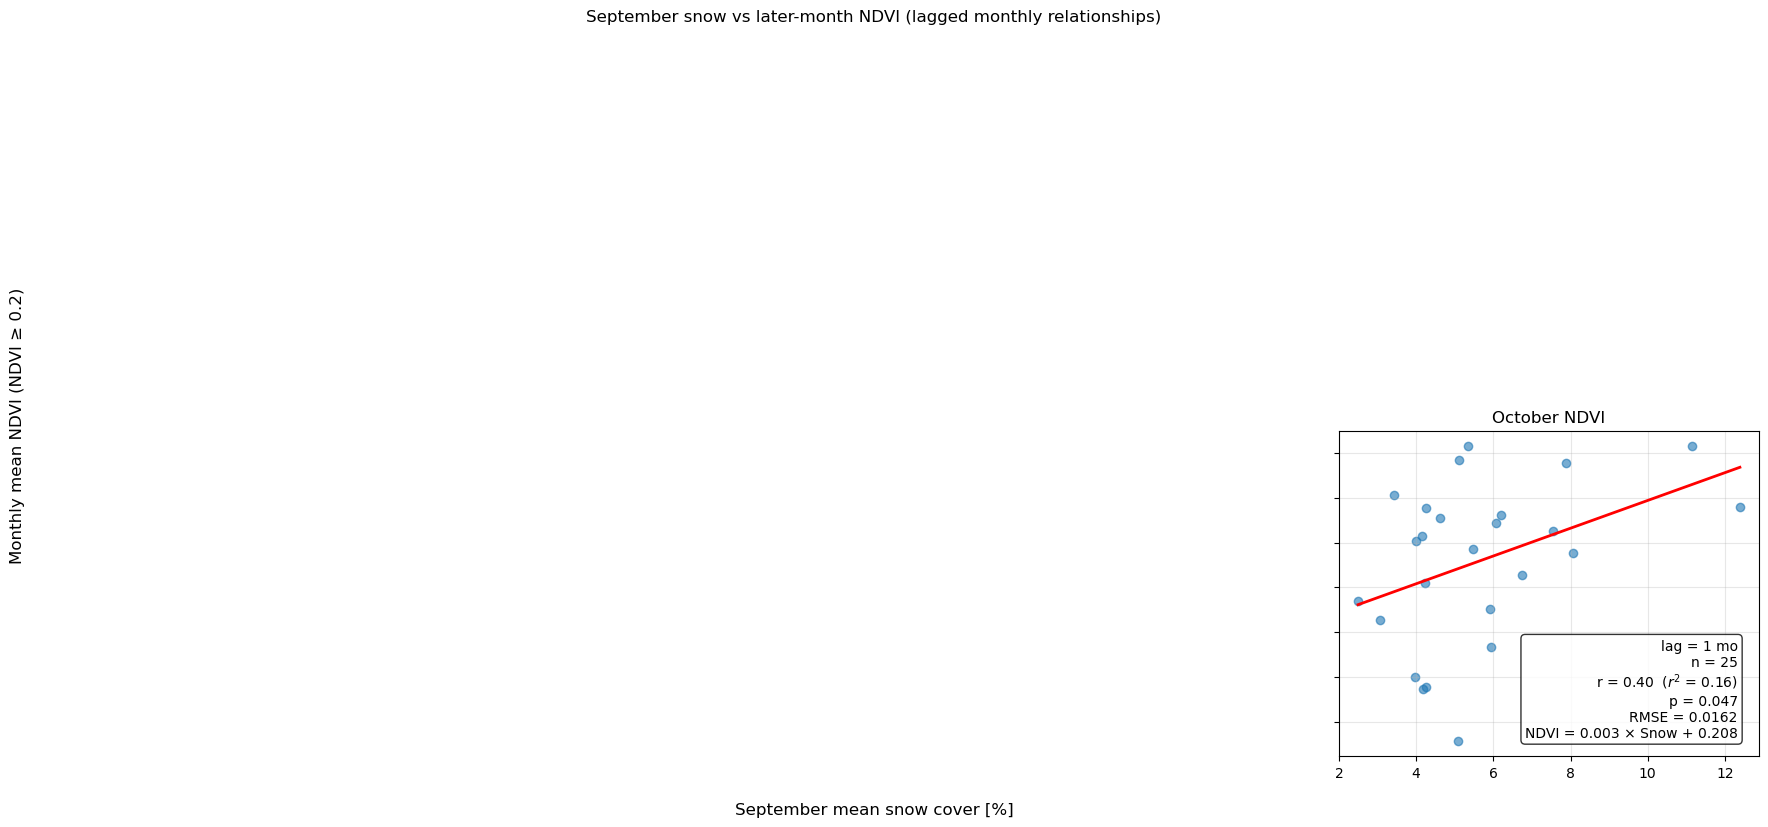

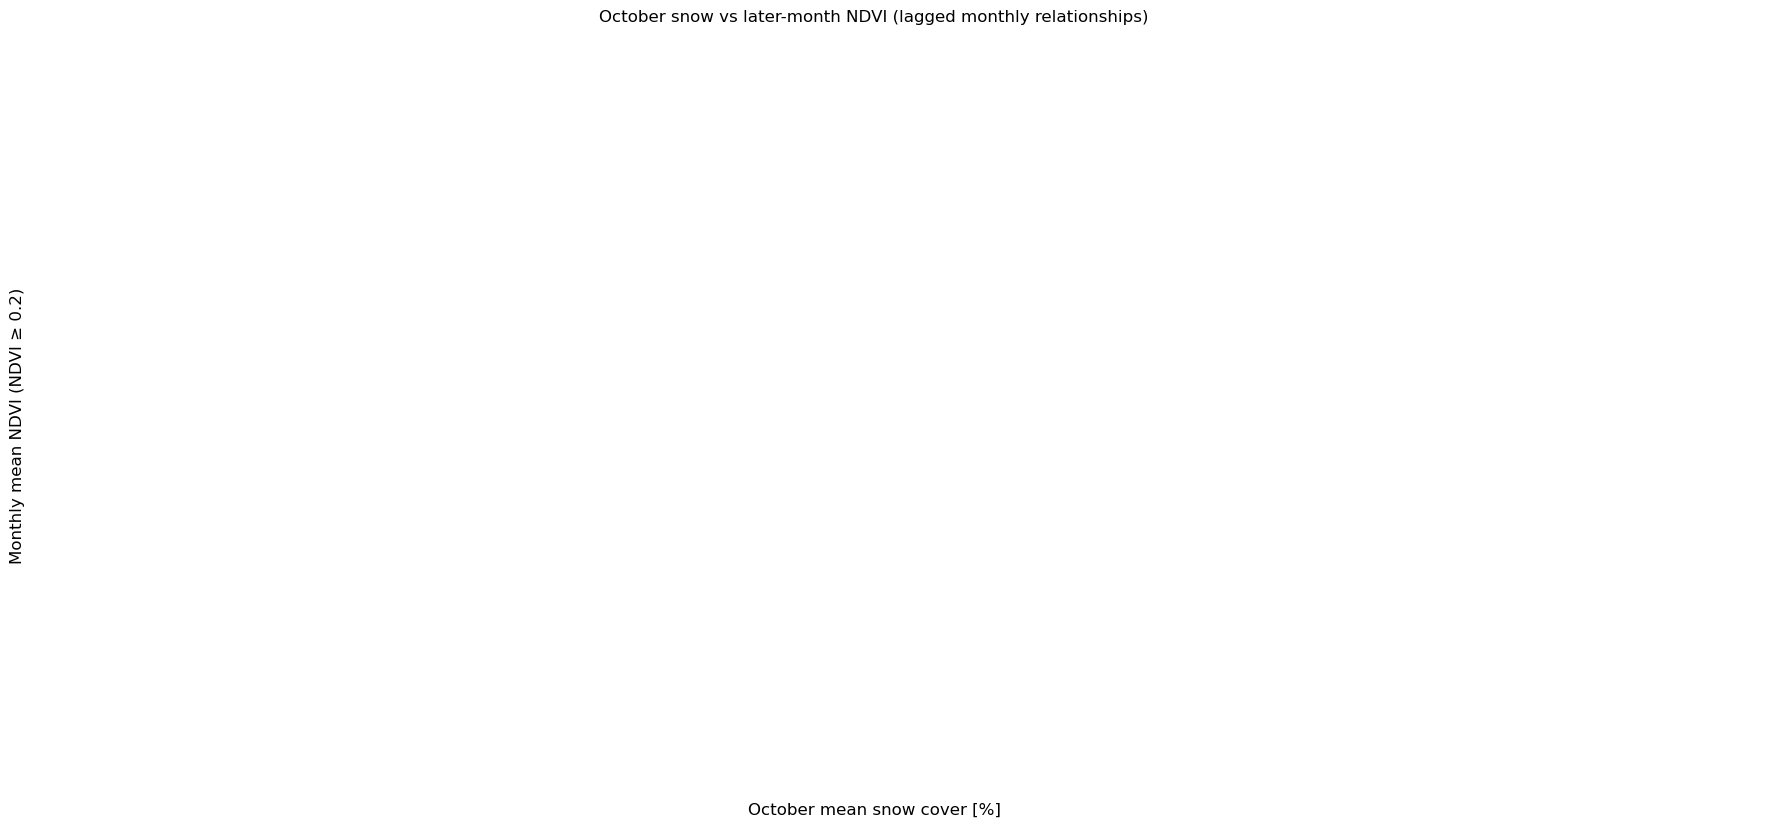

In [39]:
months = [3, 4, 5, 6, 7, 8, 9, 10]
month_names = ['March', 'April', 'May', 'June', 'July', 'August', 'September', 'October']

ndvi_monthly = (
    ndvi_snow.groupby(['Year', 'Month'], as_index=False)
    .agg(NDVI=('NDVI', 'mean'))
)

for i, snow_name in zip(months, month_names):

    # Snow monthly means for the snow month i
    month_snow = (
        ndvi_snow[ndvi_snow['Month'] == i]
        .groupby('Year', as_index=False)['Snow_Percent']
        .mean()
        .rename(columns={'Snow_Percent': f'{snow_name}_Snow'})
    )

    # One figure per snow month: NDVI months laid out consistently across the grid
    fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, m, ndvi_name in zip(axes, months, month_names):

        if m <= i:
            ax.axis('off')
            continue

        ndvi_m = ndvi_monthly[ndvi_monthly['Month'] == m].copy()
        aligned = month_snow.merge(ndvi_m, on='Year', how='inner')

        x = aligned[f'{snow_name}_Snow']
        y = aligned['NDVI']

        ax.scatter(x, y, alpha=0.6)

        if len(aligned) >= 3:
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

            y_pred = intercept + slope * x
            rmse = np.sqrt(np.mean((y - y_pred) ** 2))
            
            x_fit = np.linspace(x.min(), x.max(), 100)
            y_fit = intercept + slope * x_fit

            # Colour by significance
            sig = (p_value <= 0.05)
            line_colour = 'r' if sig else 'grey'
            ax.plot(x_fit, y_fit, linewidth=2, color=line_colour)

            n_obs = len(aligned)
            p_txt = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.3f}"

            ax.text(
                0.95, 0.05,
                f'lag = {m - i} mo\n'
                f'n = {n_obs}\n'
                f'r = {r_value:.2f}  ($r^2$ = {r_value**2:.2f})\n'
                f'{p_txt}\n'
                f'RMSE = {rmse:.4f}\n'
                f'NDVI = {slope:.3f} × Snow + {intercept:.3f}',
                transform=ax.transAxes,
                va='bottom', ha='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
            )
        else:
            ax.text(
                0.95, 0.05,
                'n < 3',
                transform=ax.transAxes,
                va='bottom', ha='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
            )

        ax.set_title(f'{ndvi_name} NDVI')
        ax.grid(True, alpha=0.3)

    # Axis labels / title per figure
    fig.supxlabel(f'{snow_name} mean snow cover [%]')
    fig.supylabel('Monthly mean NDVI (NDVI ≥ 0.2)')
    fig.suptitle(f'{snow_name} snow vs later-month NDVI (lagged monthly relationships)', y=1.02)

    #for ax in axes:
    #     if ax.has_data():
    #         ax.set_xlim(20, 60)
    #         ax.set_ylim(0.2, 0.4)

    plt.tight_layout()
    plt.show()
